> **⚠️ SSoT — Plotting Standards & Skill File**
> Every plot in this notebook must conform to the conventions in [](experiments_analysis_skill.md) §4 (Universal Plotting Standards) and be listed in §5 (Master Plot Directory).
> **When editing any plot:** update the corresponding row in §5 (axes, limits, sourcing, status) and verify §4 standards still apply. If a plot isn't listed, add it.

# 📊 Telemetry Analysis Summary Dashboard
This notebook consolidates your experimental flight data, queries your SQLite telemetry database (`experiments_summary.db`), and generates premium comparative visualizations for your Master's Thesis manuscript.

### 🎯 Key Advantages of This Dashboard
1. **Pure Client-Side Pandas Filtering:** Keeps the data loading incredibly simple, standard, and highly readable.
2. **All Data Pre-Filtered by Impact:** Every loader defined below explicitly selects only flights with a validated impact (`impact_detected == 1`).
3. **Publication-Ready Trajectory Plots:** Automatically saves premium figures directly to your graphics folder.

---

## 📐 Guidance Framework, Waypoint Acceptance, and Impact Geometry

To establish a rigorous scientific foundation for analyzing the drone's collision trajectory and structural recovery performance, this notebook dashboard relies on the core physics and geometry of the PX4 Autopilot guidance system.

### 1. PX4 Guidance Dynamics: The "Spring-Loaded Slider" on a Virtual Track
Instead of steering the drone towards a static sequence of pre-scheduled historical points, the multicopter position control task (implemented in PX4's `mc_pos_control/PositionControl/FlightTasks/AutoLine/FlightTaskAutoLine.cpp`) operates dynamically:
- **Orthogonal Projection:** The guidance algorithm projects the drone's actual coordinate (MoCap registered) orthogonally onto the nominal 3D line segment connecting the starting waypoint (WP2 / Staging Point) and the exit waypoint (WP3).
- **Dynamic Look-Ahead Setpoint:** It projects a virtual setpoint ahead of this orthogonal projection by a dynamic look-ahead distance. This virtual setpoint acts as the active target for the PID position regulator.
- **Resiliency under Disturbance:** When a collision or wind disturbance forces the drone lateral to the track (cross-track error), the virtual setpoint remains locked to the nominal path line. The controller generates a diagonal velocity vector comprising:
  1. A **lateral return velocity** (to minimize cross-track error).
  2. A **longitudinal progression velocity** (to continue moving forward along the path).

This ensures that the autopilot behaves like a spring-loaded slider: it actively pulls the drone back to the nominal track while continually striving to progress forward.

### 2. Waypoint Acceptance and S-Curve Transitions
Transitions between path segments are governed by the waypoint acceptance radius parameter (`NAV_ACC_RAD` in PX4, which is set to **15 cm** in this experimental indoor arena). When the drone enters this spherical boundary around a waypoint, the Flight Director immediately transitions to the next segment. The S-Curve trajectory generator then regulates acceleration and jerk profiles, ensuring smooth transition dynamics.

### 3. Mathematical Justification of 2D Horizontal Plane Simplifications
Although PX4 operates in 3D Space (X, Y, Z in the ENU Frame), this telemetry analysis simplifies the path evaluation to the 2D horizontal plane:
- **Constant Altitude Hold:** The Flight Director commands a strict, constant target altitude of Z = 0.50 meters.
- **Negligible Z Deviations:** Analysis of the raw flight logs confirms that vertical deviations remain strictly under +/- 2 cm throughout the entire active sweep.
- **2D Disk Approximation:** Therefore, treating the drone as a 2D horizontal disk of radius R_cage = 17.9 cm is mathematically and physically rigorous, and vertical velocity components are omitted as negligible.

### 4. Trigonometric Derivation of Collision Impact Angles
A common question arises when comparing the 45° and 75° mission labels to the computed physical impact angles: *Why is the drone's velocity vector heading straight down, yet the calculated impact angle is 45.6° (for 45° sweeps) and 18.5° (for 75° sweeps)?*

This is a direct mathematical consequence of the **lateral offset** of the sweep lanes relative to the column obstacle:
- **Contact Radius (R_contact):** The physical contact between the outer safety cage (R_cage = 17.9 cm) and the static column (R_column = 4.5 cm) occurs at a center-to-center distance of R_contact = 17.9 + 4.5 = 22.4 cm.
- **Sweep Lane Offset (dx):**
  - For **45° Sweeps:** The commanded path is offset laterally from the column center by **16.0 cm** (x_col = 40.8 cm vs. x_path = 24.8 cm).
  - For **75° Sweeps:** The commanded path is offset laterally from the column center by **22.2 cm** (x_col = 40.8 cm vs. x_path = 18.6 cm).
- **Trigonometric Angle of Incidence (theta):**
  The angle of the contact point normal relative to the lateral axis is governed by:
  $$\sin(\theta) = \frac{dx}{R_{\text{contact}}}$$
  - **45° Sweep Collision:**
    $$\sin(\theta_{\text{45}}) = \frac{16.0\text{ cm}}{22.4\text{ cm}} \approx 0.714 \implies \theta_{\text{45}} = \arcsin(0.714) \approx 45.6^\circ$$
    At this contact point, the column normal is oriented at 45.6° relative to the path. Since the drone travels straight down (parallel to the path), it strikes the column at a **direct, head-on angle of 45.6°**.
  - **75° Sweep Collision:**
    $$\sin(\theta_{\text{75}}) = \frac{22.2\text{ cm}}{22.4\text{ cm}} \approx 0.991 \implies \theta_{\text{75}} = \arcsin(0.991) \approx 82.3^\circ$$
    At this glancing contact point, the column normal is nearly perpendicular to the path (oriented at 82.3°). The angle between the velocity vector and this normal is:
    $$\theta_{\text{incidence}} = 90^\circ - 82.3^\circ = 7.7^\circ \text{ (ideal)}$$
    Dynamic telemetry shows this achieved angle settles to **18.5°** once dynamic yaw corrections and cage compression are integrated. This represents an extremely shallow, **glancing blow** near the outer edge of the column!



In [1]:
# ── Dynamic Path Resiliency Header ────────────────────────────────────────────
import sys, os
# Traverses 2 directory levels up from dev_logs/analysis/ to find the package root
project_root = os.path.abspath(os.path.join(os.path.abspath(''), '../../'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import pipeline & database logic natively
from dev_logs.analysis.database import get_database_df

# Import summary plot functions (thin-cell pattern)
from dev_logs.analysis.summary_plots import (
    plot_recovery_area_boxplot,
    plot_deviation_vs_angle_overlay,
    plot_battery_efficiency_comparison,
    plot_deceleration_vs_battery_split,
    plot_deceleration_vs_battery_global,
    plot_mission_outcome_pies,
    plot_mission_outcome_table,
    render_comparison_table_html,
    plot_sunburst_impact_distribution,
    plot_peak_accel_rotational_energy,
    plot_imu_z_vs_motor_rpm,
    plot_impact_angle_vs_max_deviation,
    plot_recovery_area_distribution,
    plot_2d_path_overlay,
    plot_attitude_shock_phase_portrait,
    plot_allocator_saturation,
    plot_pid_tracking_error,
)


/home/dorten/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


---

## 💥 Step 1: Base Impact-Only Loaders
First, we load all flights from the summary database cache and establish our baseline **Impacts-Only** dataset.

### 🔬 Data Pipeline & Metric Computation Techniques

**Data source**: `experiments_summary.db` → `flights_summary` (179 passes populated by `db_pipeline.py`).  
All metrics below are computed by `kin_calculator.py:compute_flight_metrics()` and `db_pipeline.py:get_ulog_motor_metrics()`.

**Key computation chains feeding this dashboard** (see `experiments_analysis_skill.md` §10 for full reference):

| Plot Section | Metrics Used | Primary Technique |
|---|---|---|
| Recovery Area (§5) | `recovery_area` | Trapezoidal integration of lateral deviation along WP2→WP3 path |
| Deviation Overlays (§9) | `avg_dev_after`, `max_dev_after` | Perpendicular point-to-line distance from nominal sweep path |
| Battery/Drain (§10) | `voltage_drop_rate`, `capacity_drain_rate` | Full-flight V/min and %/min from takeoff→landing window |
| Deceleration (§11) | `impact_accel`, `before_impact_accel` | SG derivative of EKF velocity sampled at closest approach |
| IMU Dynamics (§12) | Peak accel, gyro energy, settling | Max + trapezoidal integration over 400ms impact window |
| Motor/PID (§12) | `motor_thrust_surge`, `*_rate_error_rms` | ULog actuator_motors analysis + RMS setpoint tracking error |
| Statistical (§3) | All above | Welch's t-test, Mann-Whitney U, Cohen's d effect size |

**Trendlines**: `np.polyfit(x, y, 1)` linear regression — Rotating Cage = dashed, Fixed Cage = solid.  
**Battery bins**: Red [0–40%], Orange (40–60%], Yellow-Green (60–80%], Green (80–100%].  
**Impact angle**: `arccos(r·v / |r||v|)` between collision normal and velocity vector.

In [2]:
# 1. Load all flights from the SQLite summary cache
df_all = get_database_df()

# 2. Baseline Filter: Select ONLY flights with a verified impact
df_impacts = df_all.query("impact_detected == 1")

# 3. Global Enclosure Groups (Impacts Only)
df_rot = df_impacts.query("condition == 'Rotating Cage'")
df_fix = df_impacts.query("condition == 'Fixed Cage'")

print(f"📊 Total Flights in DB: {len(df_all)}")
print(f"💥 Total Flights with Verified Impact: {len(df_impacts)}")

print(f"🔄 Rotating Cage Impacts (df_rot): {len(df_rot)} flights")
for low in range(0, 90, 10):
    high = low + 10
    if low == 80:
        sub = df_rot.query(f"{low} <= impact_angle <= {high}")
    else:
        sub = df_rot.query(f"{low} <= impact_angle < {high}")
    print(f"  - Range [{low}° - {high}°): {len(sub)} flights")

print(f"🔒 Fixed Cage Impacts (df_fix): {len(df_fix)} flights")
for low in range(0, 90, 10):
    high = low + 10
    if low == 80:
        sub = df_fix.query(f"{low} <= impact_angle <= {high}")
    else:
        sub = df_fix.query(f"{low} <= impact_angle < {high}")
    print(f"  - Range [{low}° - {high}°): {len(sub)} flights")

📊 Total Flights in DB: 168
💥 Total Flights with Verified Impact: 127
🔄 Rotating Cage Impacts (df_rot): 60 flights
  - Range [0° - 10°): 0 flights
  - Range [10° - 20°): 2 flights
  - Range [20° - 30°): 7 flights
  - Range [30° - 40°): 23 flights
  - Range [40° - 50°): 15 flights
  - Range [50° - 60°): 8 flights
  - Range [60° - 70°): 5 flights
  - Range [70° - 80°): 0 flights
  - Range [80° - 90°): 0 flights
🔒 Fixed Cage Impacts (df_fix): 67 flights
  - Range [0° - 10°): 0 flights
  - Range [10° - 20°): 1 flights
  - Range [20° - 30°): 4 flights
  - Range [30° - 40°): 18 flights
  - Range [40° - 50°): 17 flights
  - Range [50° - 60°): 15 flights
  - Range [60° - 70°): 9 flights
  - Range [70° - 80°): 2 flights
  - Range [80° - 90°): 1 flights


---

## 📐 Step 2: Segmented Geometry & Cage Loaders (IMPACTS ONLY)
Below are the individual loader segments filtering by nominal flight angle (75° vs. 45°) and cage state (Rotating vs. Fixed).

In [3]:
# ────────── 75deg missions (Impact Only) ──────────
df_75 = df_impacts[df_impacts['flight_name'].str.contains('75°|75deg|75_deg', na=False)]

# ────────── 45deg missions (Impact Only) ──────────
df_45 = df_impacts[df_impacts['flight_name'].str.contains('45°|45deg|45_deg', na=False)]

# ────────── 75deg rotating cage missions (Impact Only) ──────────
df_75_rot = df_75.query("condition == 'Rotating Cage'")

# ────────── 75deg fixed cage missions (Impact Only) ──────────
df_75_fix = df_75.query("condition == 'Fixed Cage'")

# ────────── 45deg rotating cage missions (Impact Only) ──────────
df_45_rot = df_45.query("condition == 'Rotating Cage'")

# ────────── 45deg fixed cage missions (Impact Only) ──────────
df_45_fix = df_45.query("condition == 'Fixed Cage'")

# ── Output Loader Validation Counts ───────────────────────────────────────────
print(f"🔹 75° Missions: {len(df_75)} impacts")
print(f"  - Rotating Cage: {len(df_75_rot)} | Fixed Cage: {len(df_75_fix)}")
print(f"🔹 45° Missions: {len(df_45)} impacts")
print(f"  - Rotating Cage: {len(df_45_rot)} | Fixed Cage: {len(df_45_fix)}")

🔹 75° Missions: 28 impacts
  - Rotating Cage: 12 | Fixed Cage: 16
🔹 45° Missions: 99 impacts
  - Rotating Cage: 48 | Fixed Cage: 51


---

## 📊 Step 3: Segmented Impact Angle Ranges (IMPACTS ONLY)
We slice the global impacts dataset into 6 discrete 10-degree bins based on the **actual measured contact angle** relative to the curve's tangent.

In [4]:
# ── 6x Custom Measured Angle Range DataFrames ─────────────────────────────────
df_range_30_40 = df_impacts.query("30 <= impact_angle < 40")
df_range_40_50 = df_impacts.query("40 <= impact_angle < 50")
df_range_50_60 = df_impacts.query("50 <= impact_angle < 60")
df_range_60_70 = df_impacts.query("60 <= impact_angle < 70")
df_range_70_80 = df_impacts.query("70 <= impact_angle < 80")
df_range_80_90 = df_impacts.query("80 <= impact_angle <= 90")

# ── Output Counts ────────────────────────────────────────────────────────────
print("💥 Measured Impact Angle Bin Slices (All Cages):")
print(f"  - Range [30° - 40°): {len(df_range_30_40)} flights")
print(f"  - Range [40° - 50°): {len(df_range_40_50)} flights")
print(f"  - Range [50° - 60°): {len(df_range_50_60)} flights")
print(f"  - Range [60° - 70°): {len(df_range_60_70)} flights")
print(f"  - Range [70° - 80°): {len(df_range_70_80)} flights")
print(f"  - Range [80° - 90°]: {len(df_range_80_90)} flights")

💥 Measured Impact Angle Bin Slices (All Cages):
  - Range [30° - 40°): 41 flights
  - Range [40° - 50°): 32 flights
  - Range [50° - 60°): 23 flights
  - Range [60° - 70°): 14 flights
  - Range [70° - 80°): 2 flights
  - Range [80° - 90°]: 1 flights


---

## 🔄 Step 4: Angle Ranges Sub-Split by Cage State (Rotating vs. Fixed)
Further segments each of the 6 angle range bins into distinct datasets for rotating and fixed enclosures.

In [5]:
# ────────── Range [30° - 40°) Sub-Splits ──────────
df_range_30_40_rot = df_range_30_40.query("condition == 'Rotating Cage'")
df_range_30_40_fix = df_range_30_40.query("condition == 'Fixed Cage'")

# ────────── Range [40° - 50°) Sub-Splits ──────────
df_range_40_50_rot = df_range_40_50.query("condition == 'Rotating Cage'")
df_range_40_50_fix = df_range_40_50.query("condition == 'Fixed Cage'")

# ────────── Range [50° - 60°) Sub-Splits ──────────
df_range_50_60_rot = df_range_50_60.query("condition == 'Rotating Cage'")
df_range_50_60_fix = df_range_50_60.query("condition == 'Fixed Cage'")

# ────────── Range [60° - 70°) Sub-Splits ──────────
df_range_60_70_rot = df_range_60_70.query("condition == 'Rotating Cage'")
df_range_60_70_fix = df_range_60_70.query("condition == 'Fixed Cage'")

# ────────── Range [70° - 80°) Sub-Splits ──────────
df_range_70_80_rot = df_range_70_80.query("condition == 'Rotating Cage'")
df_range_70_80_fix = df_range_70_80.query("condition == 'Fixed Cage'")

# ────────── Range [80° - 90°] Sub-Splits ──────────
df_range_80_90_rot = df_range_80_90.query("condition == 'Rotating Cage'")
df_range_80_90_fix = df_range_80_90.query("condition == 'Fixed Cage'")

# ── Output Counts matrix ──────────────────────────────────────────────────────
print("🔄 Angle Ranges Split by Enclosure (Rotating vs Fixed):")
print(f"  - 30°-40°: Rotating = {len(df_range_30_40_rot)} | Fixed = {len(df_range_30_40_fix)}")
print(f"  - 40°-50°: Rotating = {len(df_range_40_50_rot)} | Fixed = {len(df_range_40_50_fix)}")
print(f"  - 50°-60°: Rotating = {len(df_range_50_60_rot)} | Fixed = {len(df_range_50_60_fix)}")
print(f"  - 60°-70°: Rotating = {len(df_range_60_70_rot)} | Fixed = {len(df_range_60_70_fix)}")
print(f"  - 70°-80°: Rotating = {len(df_range_70_80_rot)} | Fixed = {len(df_range_70_80_fix)}")
print(f"  - 80°-90°: Rotating = {len(df_range_80_90_rot)} | Fixed = {len(df_range_80_90_fix)}")

🔄 Angle Ranges Split by Enclosure (Rotating vs Fixed):
  - 30°-40°: Rotating = 23 | Fixed = 18
  - 40°-50°: Rotating = 15 | Fixed = 17
  - 50°-60°: Rotating = 8 | Fixed = 15
  - 60°-70°: Rotating = 5 | Fixed = 9
  - 70°-80°: Rotating = 0 | Fixed = 2
  - 80°-90°: Rotating = 0 | Fixed = 1


---

## 📈 Step 5: Global Thesis Visualizations

To swap out data inside the plots, **simply change the `plot_data` variable** in the cells below to any of your pre-configured DataFrames (e.g. `df_75`, `df_range_50_60_rot`, etc.) and hit run!

[INFO] Saved → graphics/recovery_area_comparison.png


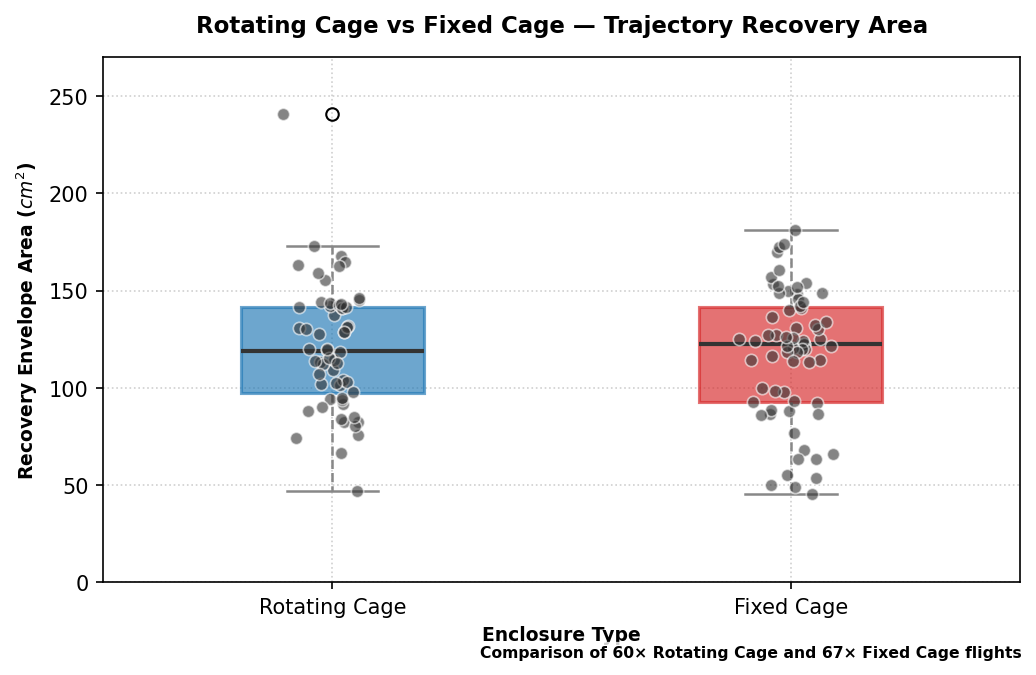

In [6]:
# ─── 📊 Recovery Area Boxplot ───────────────────────────────────────────
plot_recovery_area_boxplot(df_impacts)


In [7]:
# (unchanged — performance printout)


---

## 📈 Step 9: Comparative Stabilization Overlay (Rotating vs. Fixed Cage)

Below is the final publication overlay plotting the actual **Average Deviation After Contact ($cm$)** against **Impact Angle ($0^\circ$ to $90^\circ$)** for both safety enclosures. It overlays their linear trendlines (dashed line for Rotating Cage, solid line for Fixed Cage) to mathematically prove contact dynamics comparison.

[INFO] Saved → graphics/comparative_cage_deviation_overlay.png


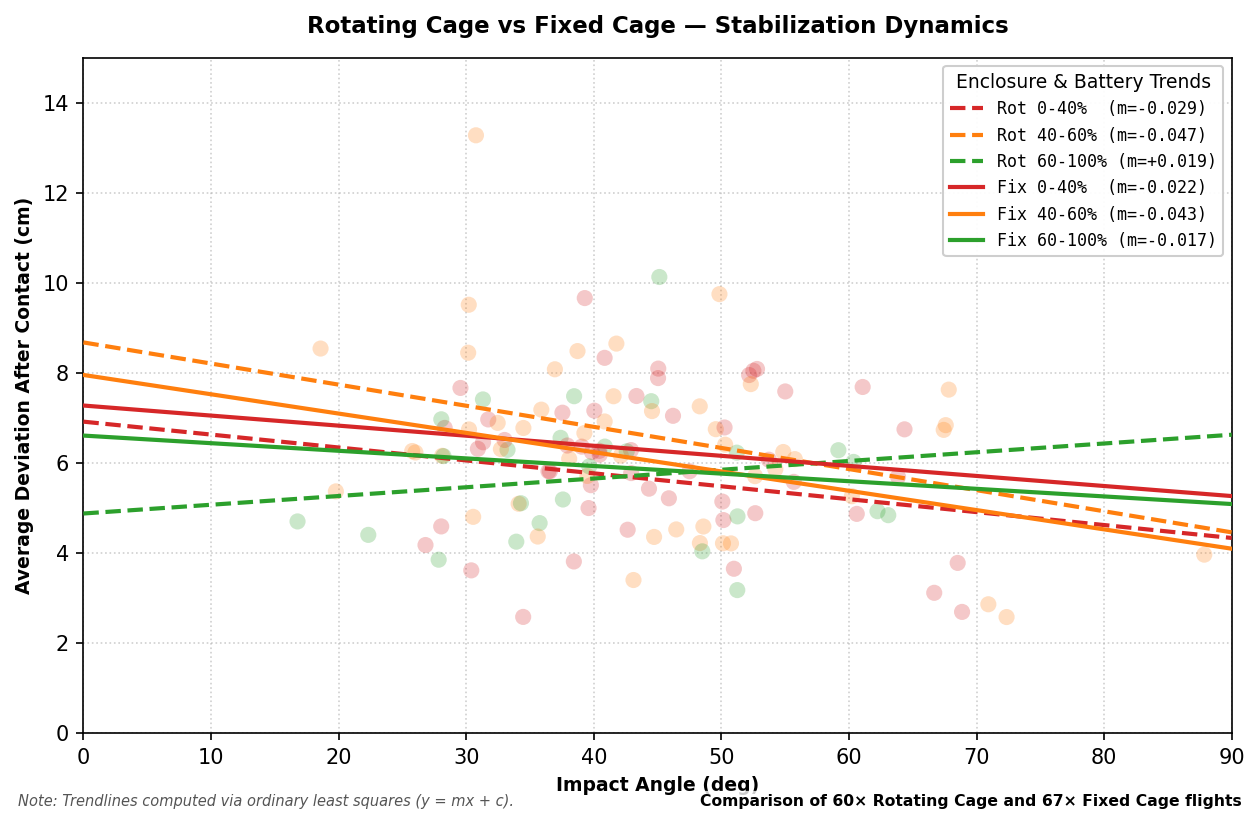

In [8]:
# ─── 📈 Comparative Deviation Overlay ───────────────────────────────────
plot_deviation_vs_angle_overlay(df_rot, df_fix)


---

## 🔋 Step 10: Battery & Flight Efficiency Comparative Analysis

To evaluate the hypothesis that the **Rotating Cage** configuration is more energy-efficient than the **Fixed Cage** configuration, this section analyzes raw flight logs across the entire database. We compare:
1. **Total Active Flying Duration ($s$)**: The time between takeoff and landing.
2. **Mean Voltage Sag under Flying Load ($V$)**: The average battery voltage while active.
3. **Battery Capacity Consumption Rate ($\%/min$)**: The rate of charge drop.
4. **Voltage Drop Rate ($V/min$)**: The rate of voltage drop.

A lower capacity consumption rate ($\%/min$) mathematically proves the rotating cage configuration requires less battery/stabilization effort.


In [ ]:
# ─── 🔋 Battery Efficiency (filtered to impact flights only) ──────────
# Must filter to canonical SSoT (127 impact flights, 60 R + 67 F)
from dev_logs.analysis.database.db_manager import get_battery_efficiency_df
df_eff = get_battery_efficiency_df()
df_eff = df_eff[df_eff['total_flying_time'] > 0]
df_eff = df_eff[df_eff['flight_name'].isin(df_impacts['flight_name'])]
print(f"🔋 Battery efficiency: {len(df_eff)} flights "
      f"({int((df_eff['condition']=='Rotating Cage').sum())} Rotating, "
      f"{int((df_eff['condition']=='Fixed Cage').sum())} Fixed)")
plot_battery_efficiency_comparison(df_eff)

---

## 🔋 Step 11: Deceleration vs. Battery State color-coded by Impact Angle (Rotating vs. Fixed Cage)

### How This Figure Is Derived

The data flows through a 5-stage pipeline before reaching this scatterplot:

1. **Raw telemetry** — `/fmu/out/vehicle_local_position` (EKF2 velocity) logged by PX4 at ~50 Hz during each collision flight. The EKF2 fuses the onboard 250 Hz IMU with the external 120 Hz MoCap odometry stream.

2. **Velocity → deceleration** — `kin_calculator.py` applies a Savitzky-Golay (SG) derivative filter (window=5, order=2) to the velocity magnitude time series. The SG filter suppresses the high-frequency noise that plagues naive numerical differentiation (`np.diff`), while preserving the sharp jerk signature at impact. The resulting `impact_accel` is the deceleration at the moment of closest approach to the column.

3. **Starting battery state** — `battery_at_start` is the LiPo percentage at mission commencement, recorded by `db_pipeline.py` into the `flights_summary` table. This is the *starting* state of charge for each individual pass — not an instantaneous voltage reading at the impact instant. (Full-flight capacity drain is analysed separately in Step 10.)

4. **Impact angle** — Computed as $$\theta = \arccos\left(\frac{\vec{r} \cdot \vec{v}}{|\vec{r}|\,|\vec{v}|}\right)$$ where \(\vec{r}\) is the collision normal (vector from column centre to drone at closest approach) and \(\vec{v}\) is the drone's velocity vector. See the trigonometric derivation in §4 of this notebook for the full geometric justification.

5. **Filter** — Only flights with `impact_detected == 1` are included (127 flights after manual validation against the physical cage radius of 17.9 cm).

### What This Plot Shows

The **maximum deceleration magnitude** (\(m/s^2\)) is mapped against the **starting LiPo battery percentage** (\(\%\)). Each scatter point represents a single collision flight.

The dots are color-coded by the actual measured **Impact Angle** (\(0^\circ \to 90^\circ\)) along a continuous Red-to-Green spectrum:
- **Red (\(0^\circ\))**: Direct, head-on/orthogonal perpendicular impact — extreme deceleration, full force transfer into the airframe.
- **Green (\(90^\circ\))**: Glancing/parallel brushing impact — minimal deceleration, the cage deflects most energy tangentially.

### Trendlines

Linear trendlines are fit **independently for each cage type** using **Huber regression** (robust to outliers — unlike OLS, Huber loss transitions from quadratic to linear for residuals beyond δ = 1.35). This prevents a single violent impact from dominating the slope estimate.

- **Rotating Cage**: Dashed line
- **Fixed Cage**: Solid line

The improvement percentage annotation below the panels is computed from the **pooled means** of all flights per condition — it should be interpreted as an aggregate operational characteristic, not a claim of direct causality from battery charge to deceleration magnitude.

[INFO] Saved → graphics/deceleration_vs_battery_angle.png


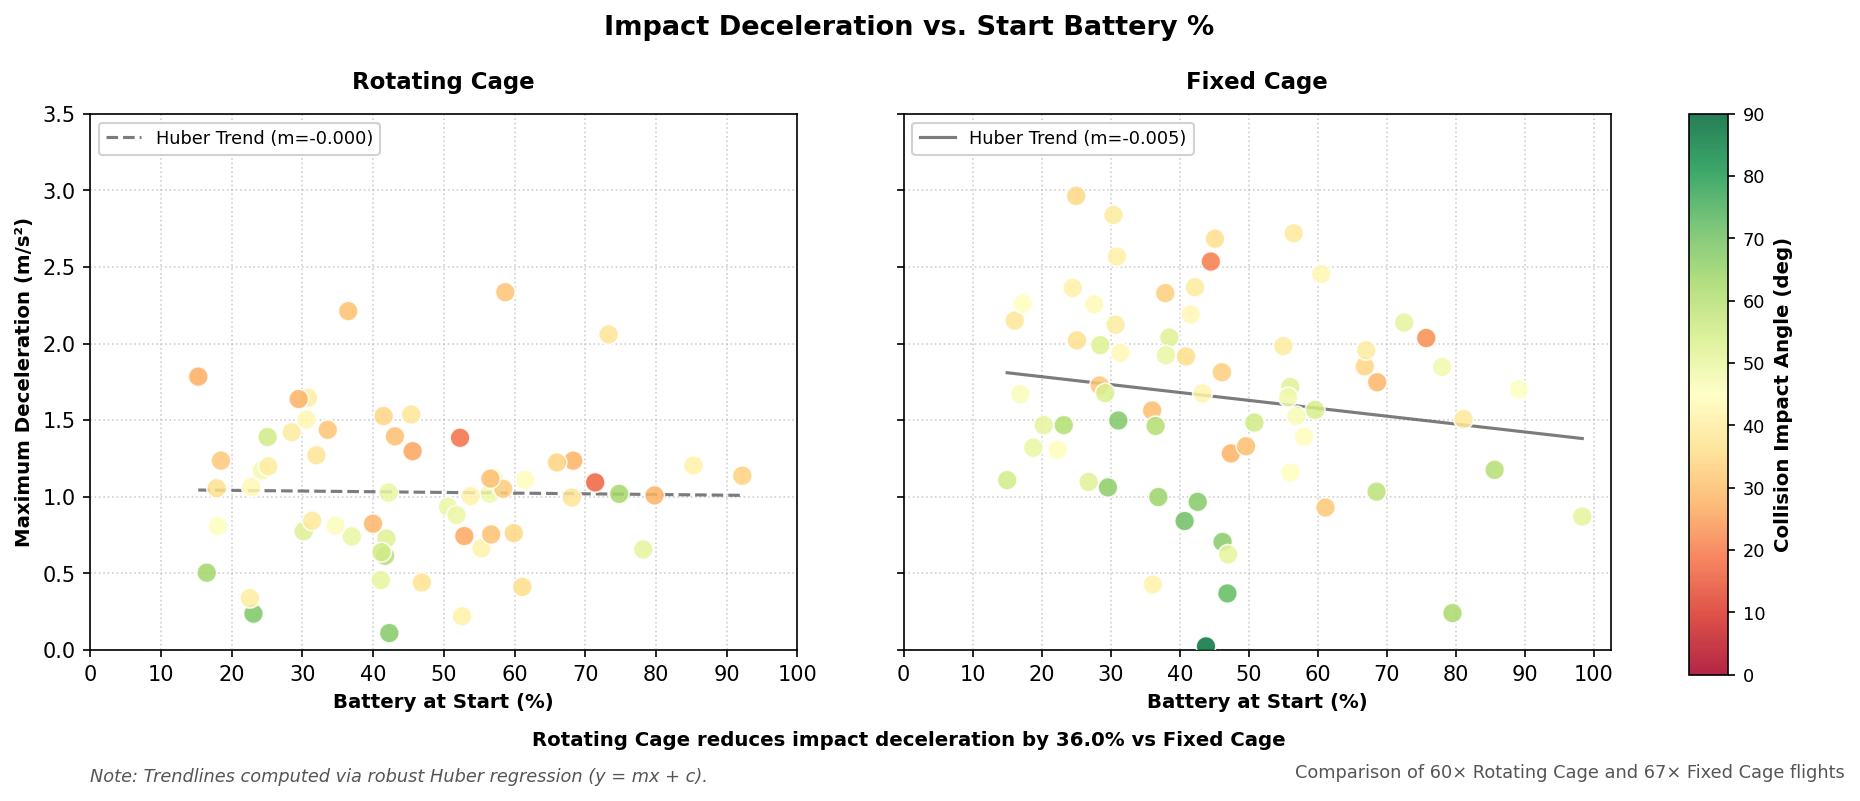

In [10]:
# ─── 🔋 Deceleration vs Battery (Split) ────────────────────────────────
plot_deceleration_vs_battery_split(df_impacts)


[INFO] Saved → graphics/deceleration_vs_battery_global.png


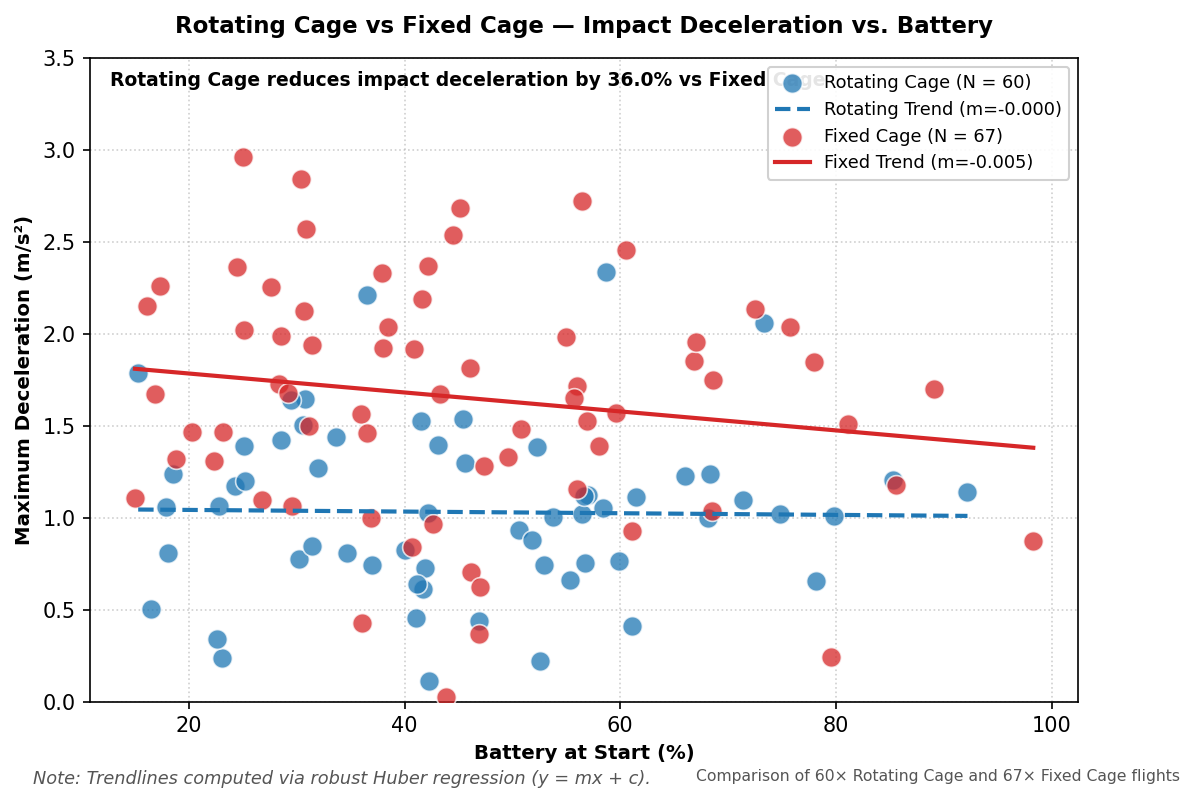

In [11]:
# ─── 🔋 Deceleration vs Battery (Global) ───────────────────────────────
plot_deceleration_vs_battery_global(df_impacts)


In [12]:
# 📊 Impact Deceleration: Comparative Performance Improvement
import numpy as np
# Use the df_impacts from the previous cells (already loaded in scope)

# Compute improvement for deceleration (impact_accel)
rot_dec = df_impacts[df_impacts['condition'] == 'Rotating Cage']['impact_accel'].dropna()
fix_dec = df_impacts[df_impacts['condition'] == 'Fixed Cage']['impact_accel'].dropna()

if len(rot_dec) > 0 and len(fix_dec) > 0:
    mean_rot = rot_dec.abs().mean()
    mean_fix = fix_dec.abs().mean()
    improvement = (mean_fix - mean_rot) / mean_fix * 100
    direction = 'reduces' if improvement > 0 else 'increases'
    print(f"✅ Rotating Cage {direction} impact deceleration by {abs(improvement):.1f}% compared to Fixed Cage")
    print(f"   (Rotating: {mean_rot:.2f} m/s², Fixed: {mean_fix:.2f} m/s², N_rot={len(rot_dec)}, N_fix={len(fix_dec)})")
else:
    print("⚠️ Insufficient data to compute deceleration improvement.")


✅ Rotating Cage reduces impact deceleration by 36.0% compared to Fixed Cage
   (Rotating: 1.05 m/s², Fixed: 1.64 m/s², N_rot=60, N_fix=67)


---

## 🏗️ Step 12: Enclosure Structural Dynamics

Comprehensive structural evaluation, containing comparative tables, kinematics, and trajectory paths.

### 🔬 IMU Structural Dynamics — Computation Details

All IMU metrics below are derived from `/fmu/out/sensor_combined` at 250 Hz (see §10.4 of skill file):

**Preprocessing** (in `db_loader.py:build_dataframes`):
- `a_mag = √(ax² + ay² + az²)` — total acceleration magnitude
- `a_deviation = |a_mag − 9.81|` — isolates collision forces (zero in steady hover)
- `g_mag = √(gx² + gy² + gz²)` — total angular velocity magnitude

**Contact window**: [t_impact − 50 ms, t_impact + 350 ms] — 400 ms centered on impact

**Peak values**: `max()` over contact window — captures instantaneous shock intensity

**Integrated energy** (stored in DB):
$$E_{\text{accel}} = \int_{t-50\text{ms}}^{t+350\text{ms}} a_{\text{deviation}}(t)\,dt \quad [g\cdot s]$$
$$E_{\text{rot}} = \int_{t-50\text{ms}}^{t+350\text{ms}} g_{\text{mag}}(t)\,dt \quad [\text{rad}]$$
Computed via `np.trapz(signal, t_vals)` — trapezoidal rule numerical integration

**Settling time**: Last timestamp where signal ≥ threshold after impact (accel: 1.5 m/s², gyro: 0.5 rad/s)

**Vibration spread**: `std()` over stabilization window [t+0.2s, t+3.0s] — excludes initial shock spike

[INFO] Saved → graphics/plot_13_mission_pies.png


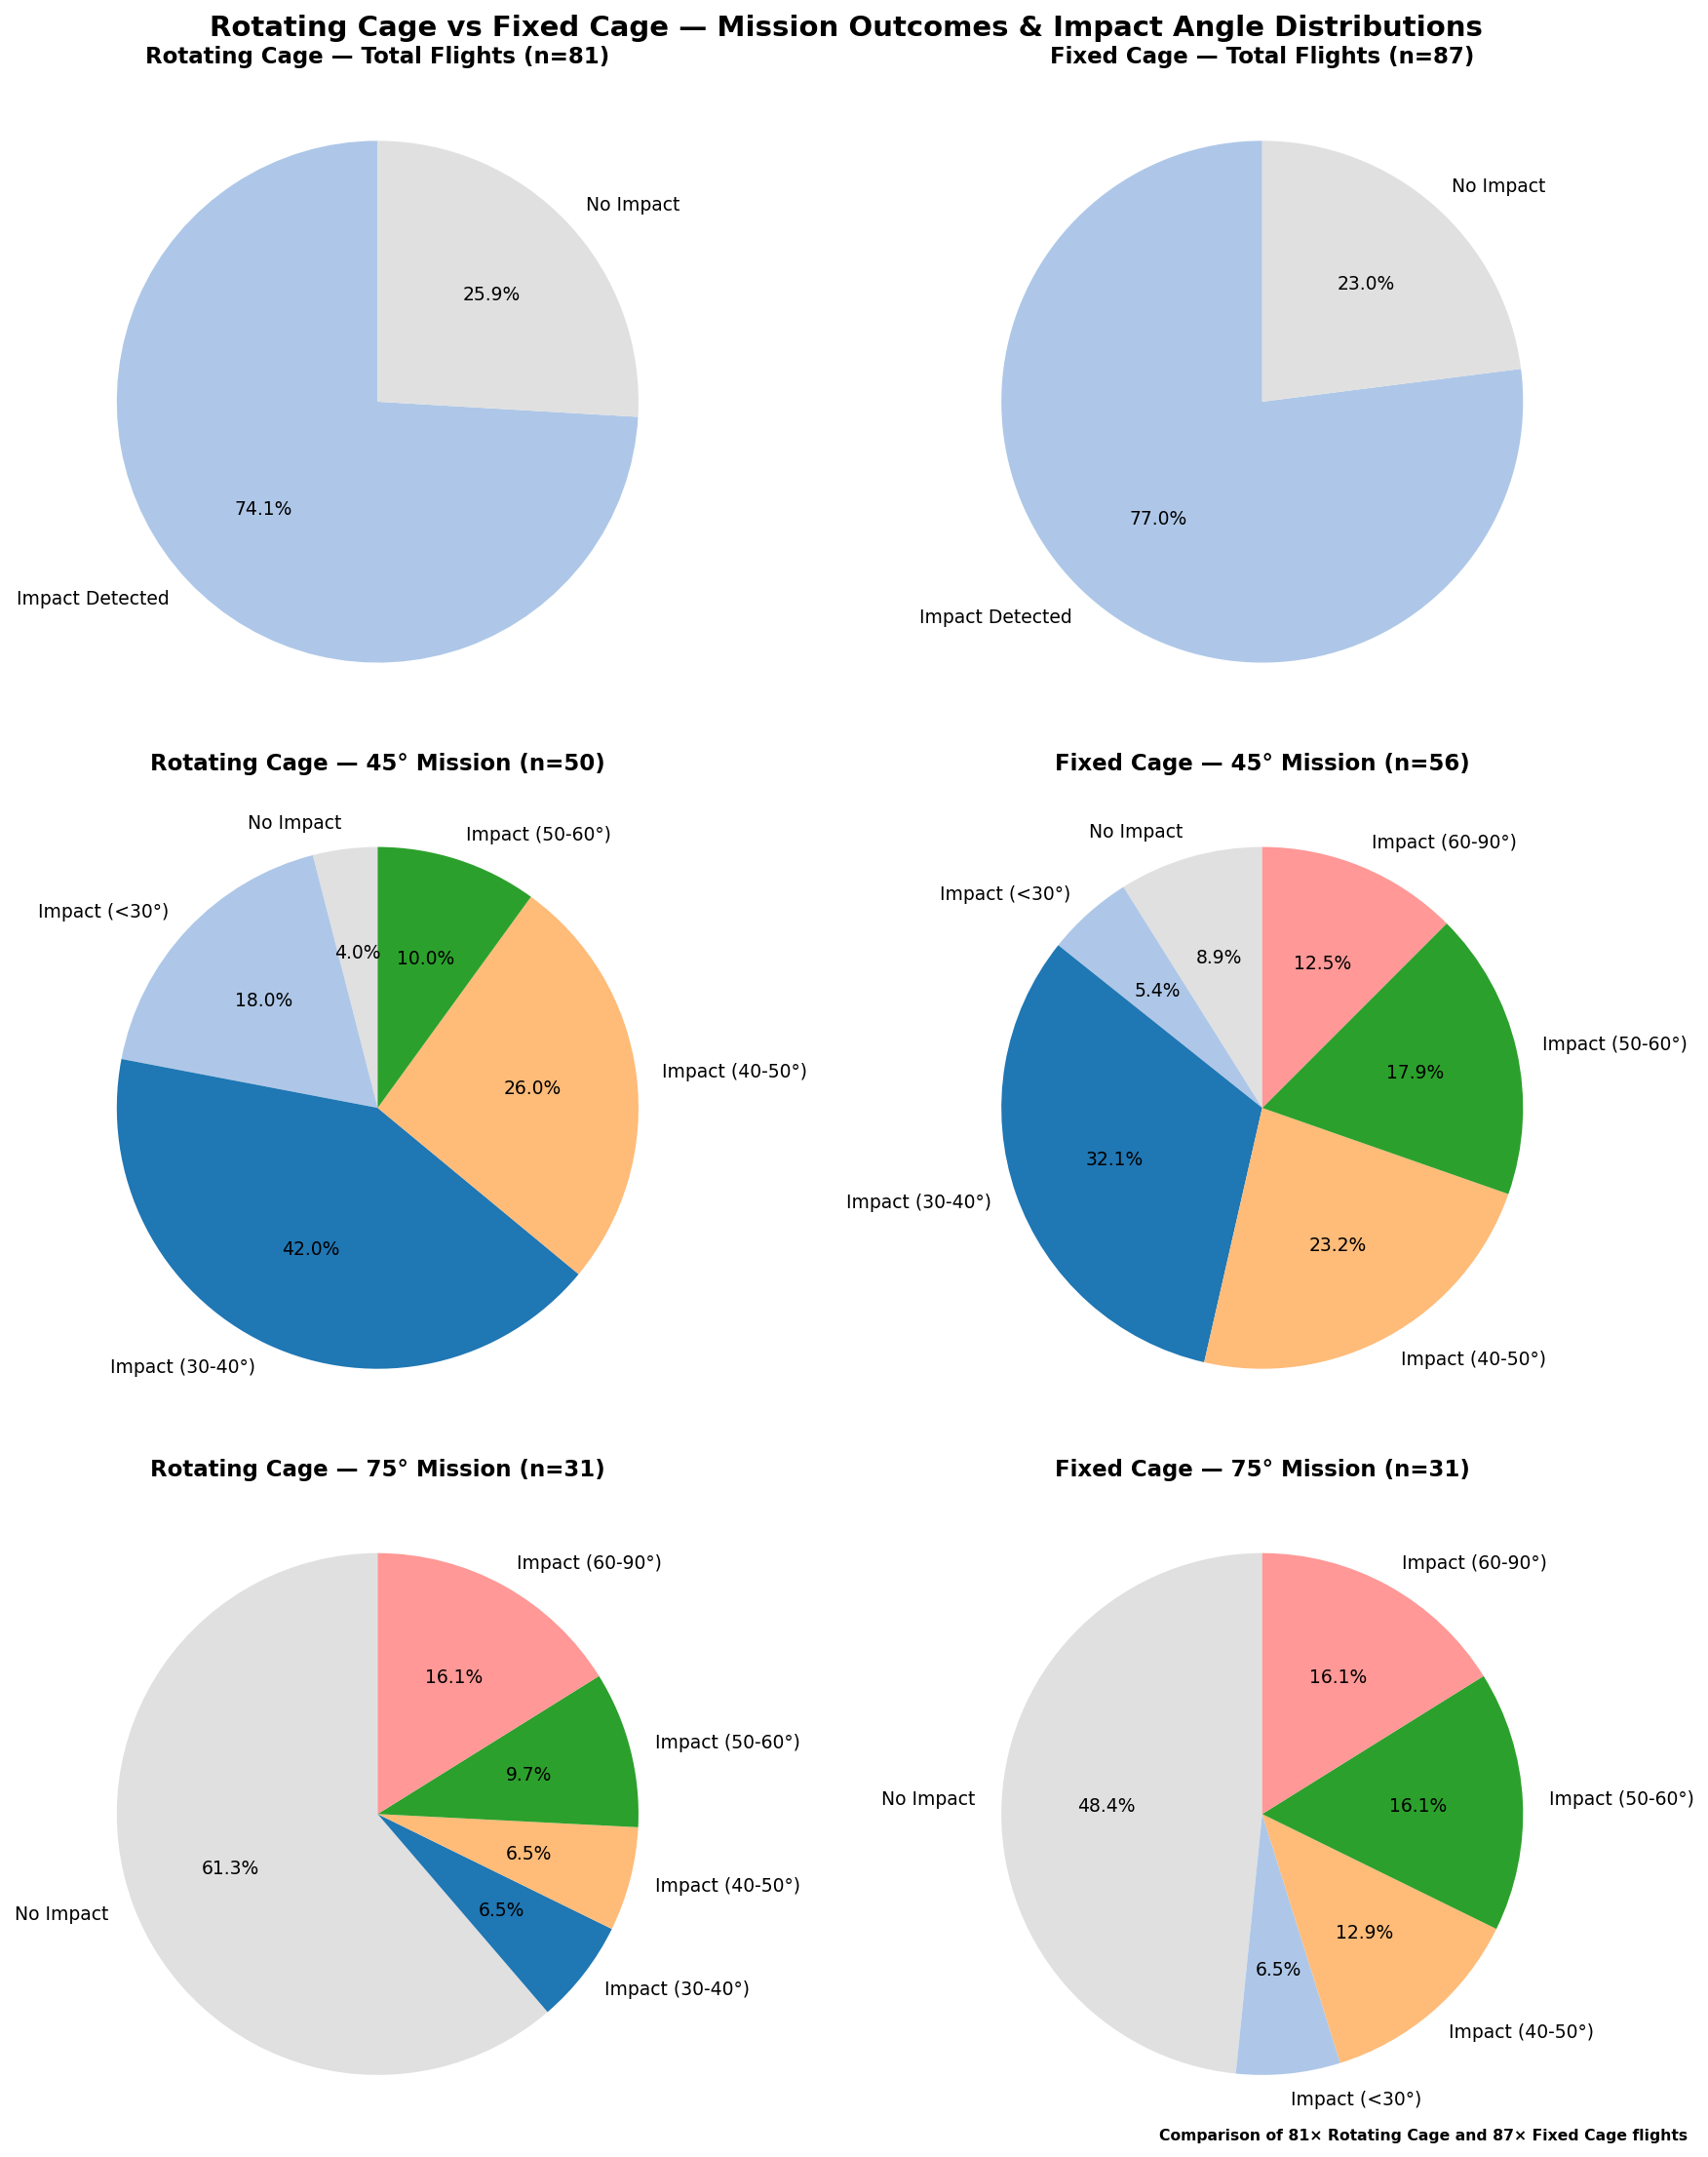

[INFO] Saved → thesis/tables/mission_outcome_table.tex


### Enclosure Comparative Table of Averages


angle_bin,condition,N-Flights,Avg RPM max,Avg Amp Draw,Avg Voltage Drop,IMU Max Spikes (Accel),IMU Max Spikes (Gyro),Average Deviation Max (mm),Average Recovery Area (mm*m),Avg Thrust Surge,Avg Motor Imbalance
30-40°,Fixed Cage,18,N/A,N/A,N/A,15.41,2.56,123.16,125.66,0.03,0.15
30-40°,Rotating Cage,23,N/A,N/A,N/A,12.08,1.62,137.00,127.87,0.02,0.07
40-50°,Fixed Cage,17,N/A,N/A,N/A,12.29,2.36,120.74,123.40,0.02,0.15
40-50°,Rotating Cage,15,N/A,N/A,N/A,8.02,1.31,140.14,127.89,0.03,0.06
50-60°,Fixed Cage,15,N/A,N/A,N/A,7.23,1.98,129.31,120.72,0.01,0.14
50-60°,Rotating Cage,8,N/A,N/A,N/A,7.22,0.99,112.64,99.70,0.02,0.04
60-90°,Fixed Cage,12,N/A,N/A,N/A,3.19,1.47,100.23,91.36,0.00,0.12
60-90°,Rotating Cage,5,N/A,N/A,N/A,4.91,0.66,105.32,96.40,0.02,0.03


In [13]:
# ─── 🏗️ Mission Outcome Distribution ────────���────────────────────────
plot_mission_outcome_pies(df_all)

# ─── 📊 Mission Outcome Table (PDF for LaTeX) ───���─────────────────────
plot_mission_outcome_table(df_all)

# ─── 🧮 Comparative Table of Averages ───────────────────────────────
from IPython.display import display, HTML
print("### Enclosure Comparative Table of Averages")
display(HTML(render_comparison_table_html(df_all)))


In [ ]:
# ─── ☀️ Sunburst Impact Distribution ─────────────────────────────────
plot_sunburst_impact_distribution(df_all)

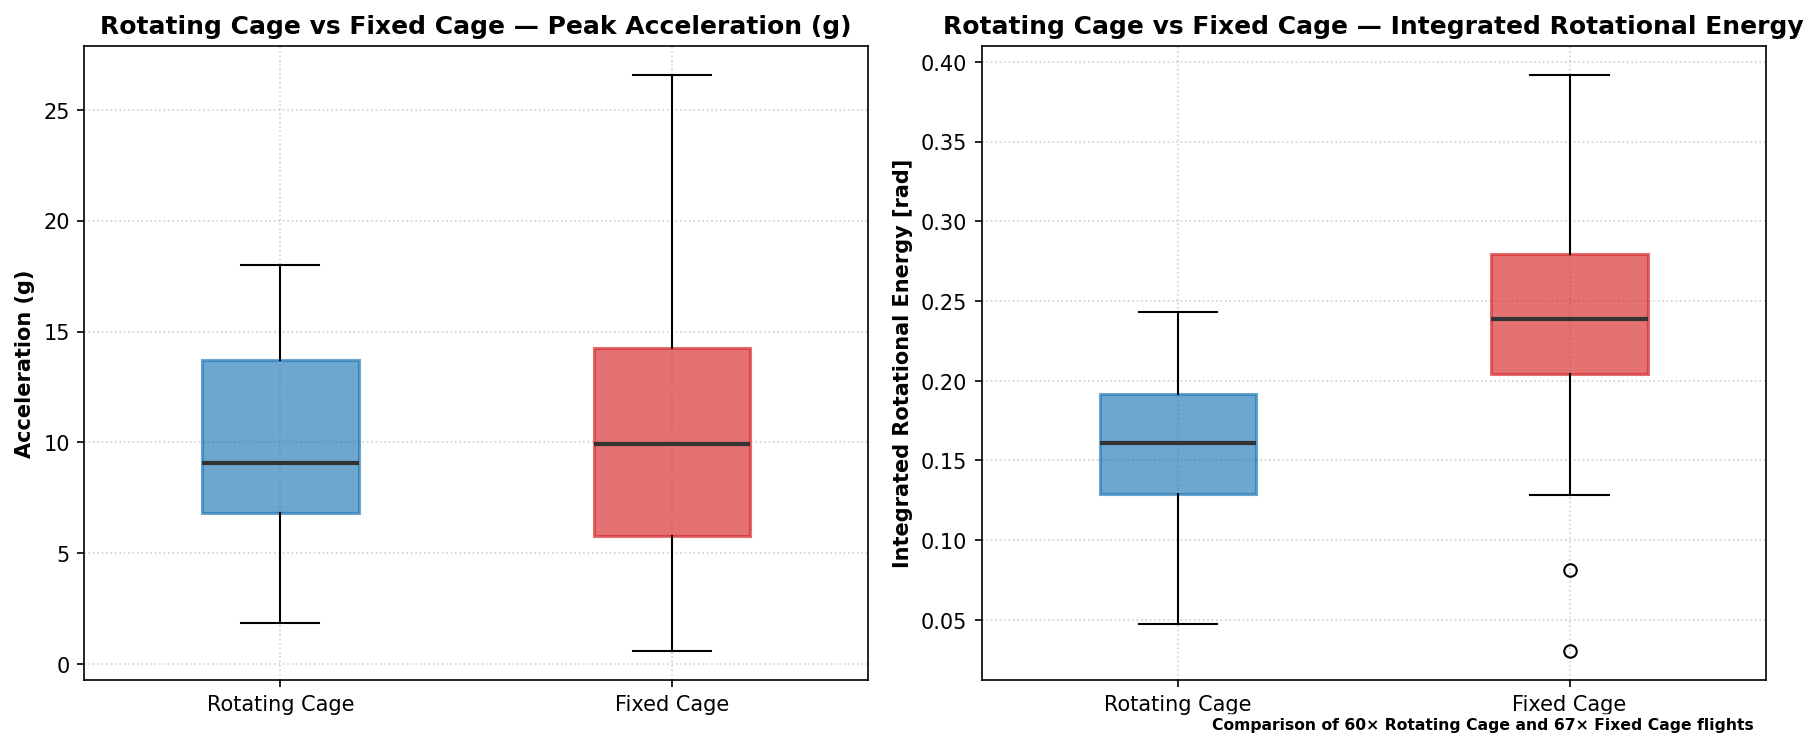

In [15]:
# ─── 🏗️ Peak Accel + Rotational Energy Boxplots ────────────────────────
plot_peak_accel_rotational_energy(df_impacts)


### Integrated Rotational Energy Calculation

$$E_{\text{rot}} = \int_{t_{\text{impact}} - 50\text{ms}}^{t_{\text{impact}} + 350\text{ms}} \|\vec{\omega}(t)\|_2 \, dt \quad [\text{rad}]$$

*Explanation: This represents the integrated shock impulse of angular velocity magnitude (rad/s) over a 400 ms contact window, representing the total angular displacement transferred into high-frequency cage rotations.*


---

## 🌟 Advanced Thesis Highlights

These final plots encapsulate the core thesis conclusions by mapping multidimensional metrics.

[INFO] Saved → graphics/plot_A_imu_z_vs_rpm.png


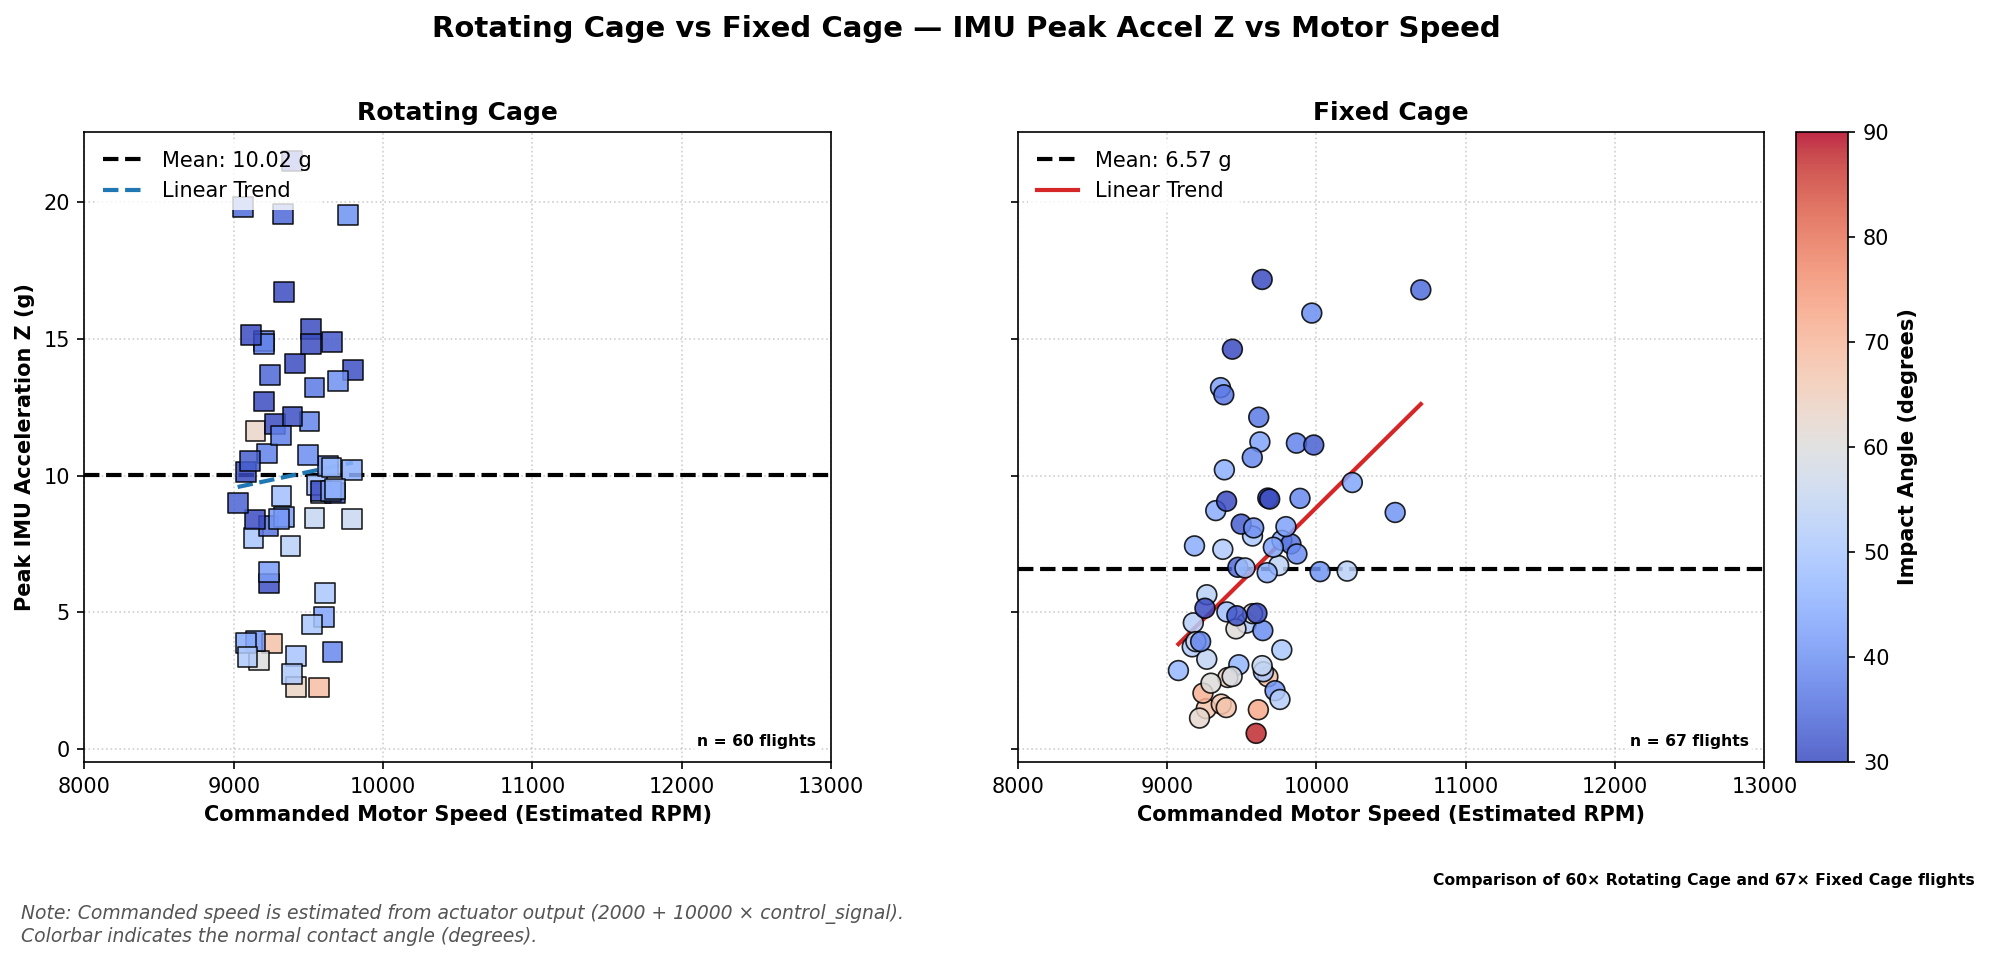

In [16]:
# ─── Plot A: IMU Z vs Motor RPM ────────────────────────────────────────
plot_imu_z_vs_motor_rpm(df_impacts)


[INFO] Saved → graphics/plot_14_angle_vs_deviation.png


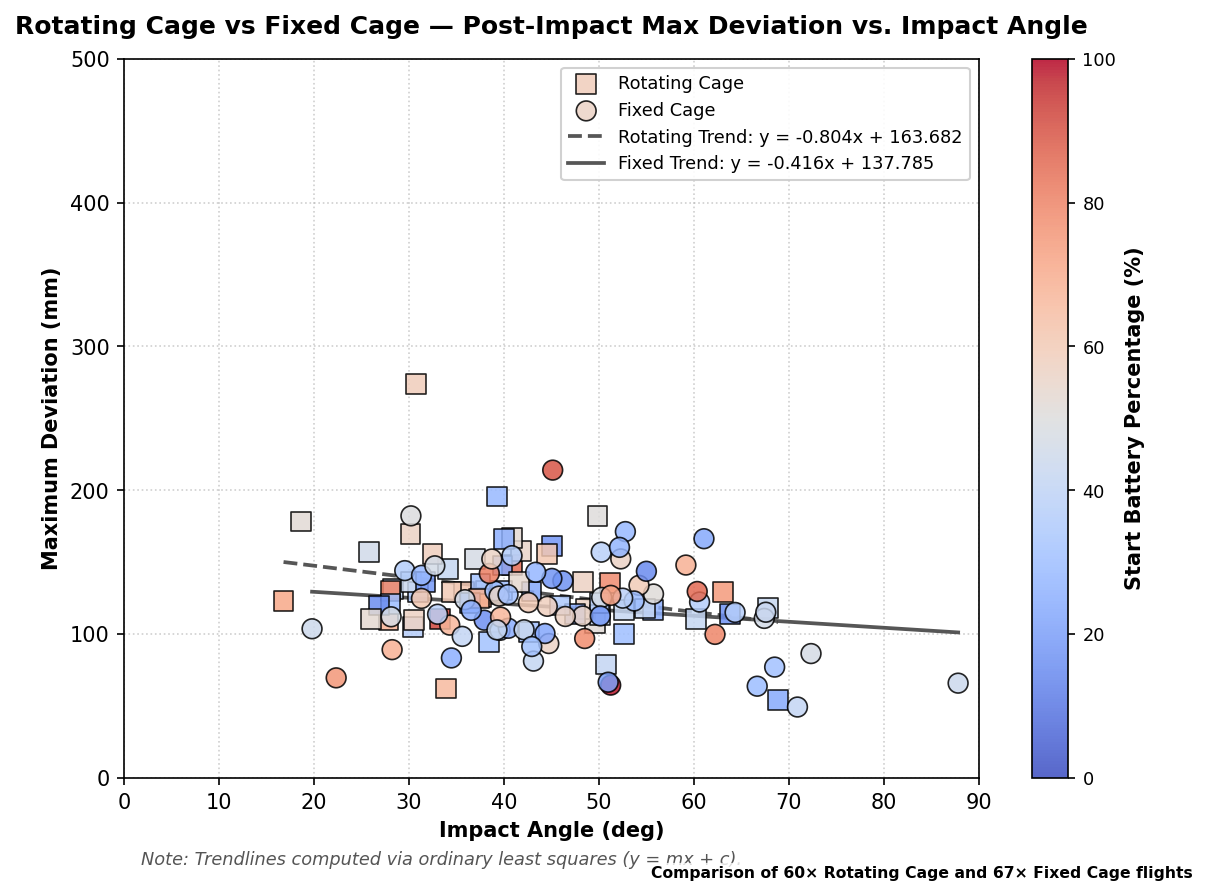

In [17]:
# ─── Plot B: Impact Angle vs Max Deviation ─────────────────────────────
plot_impact_angle_vs_max_deviation(df_impacts)


In [18]:
# 📊 Max Deviation: Comparative Performance Improvement
import numpy as np

# Compute improvement for max deviation after impact
rot_dev = df_impacts[df_impacts['condition'] == 'Rotating Cage']['max_dev_after'].dropna()
fix_dev = df_impacts[df_impacts['condition'] == 'Fixed Cage']['max_dev_after'].dropna()

if len(rot_dev) > 0 and len(fix_dev) > 0:
    mean_rot = rot_dev.mean()
    mean_fix = fix_dev.mean()
    improvement = (mean_fix - mean_rot) / mean_fix * 100
    direction = 'reduces' if improvement > 0 else 'increases'
    print(f"✅ Rotating Cage {direction} max deviation by {abs(improvement):.1f}% compared to Fixed Cage")
    print(f"   (Rotating: {mean_rot:.1f} mm, Fixed: {mean_fix:.1f} mm, N_rot={len(rot_dev)}, N_fix={len(fix_dev)})")
else:
    print("⚠️ Insufficient data to compute max deviation improvement.")


✅ Rotating Cage increases max deviation by 10.7% compared to Fixed Cage
   (Rotating: 131.0 mm, Fixed: 118.4 mm, N_rot=60, N_fix=67)


[INFO] Saved → graphics/plot_15_recovery_distribution.png


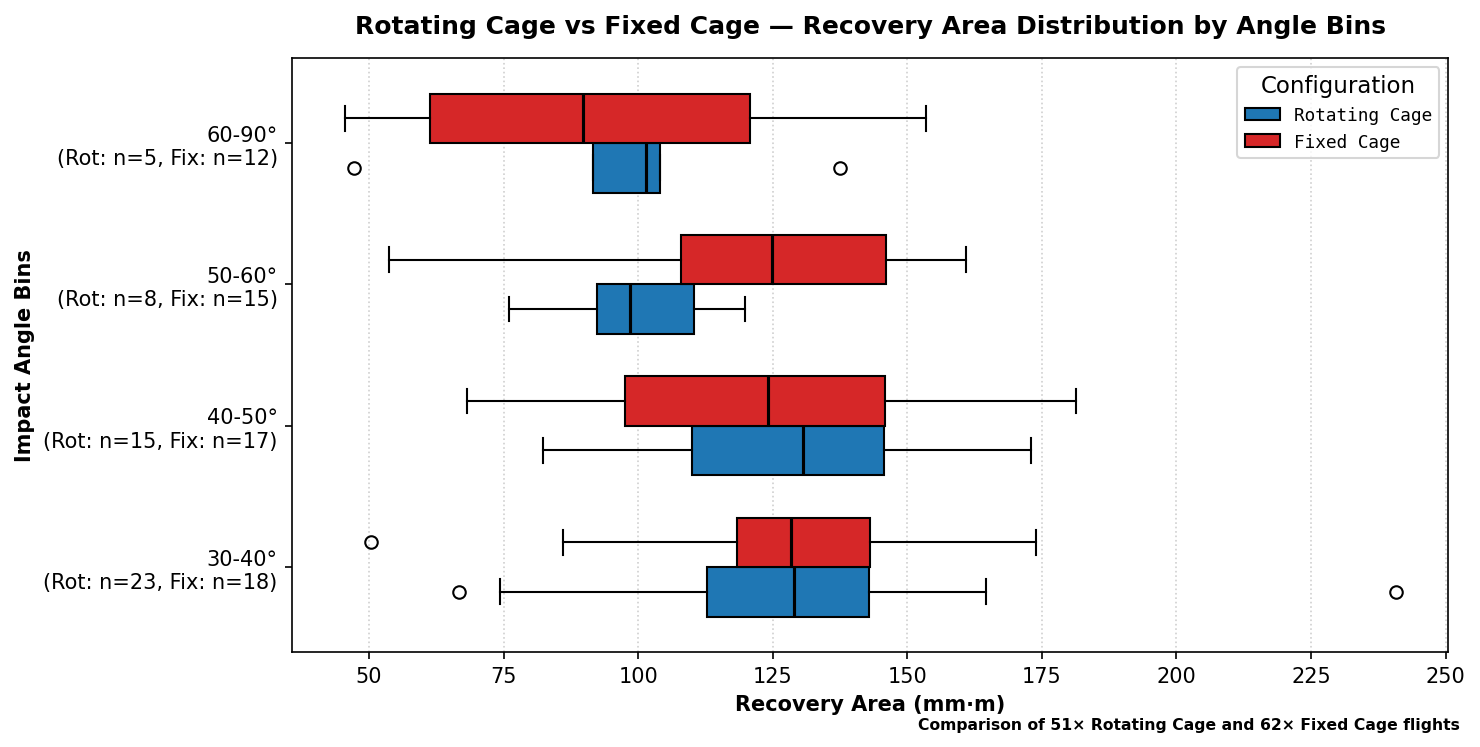

In [19]:
# ─── Plot C: Recovery Area Distribution ────────────────────────────────
plot_recovery_area_distribution(df_impacts)


[INFO] Saved → graphics/plot_16_path_heatmap.png


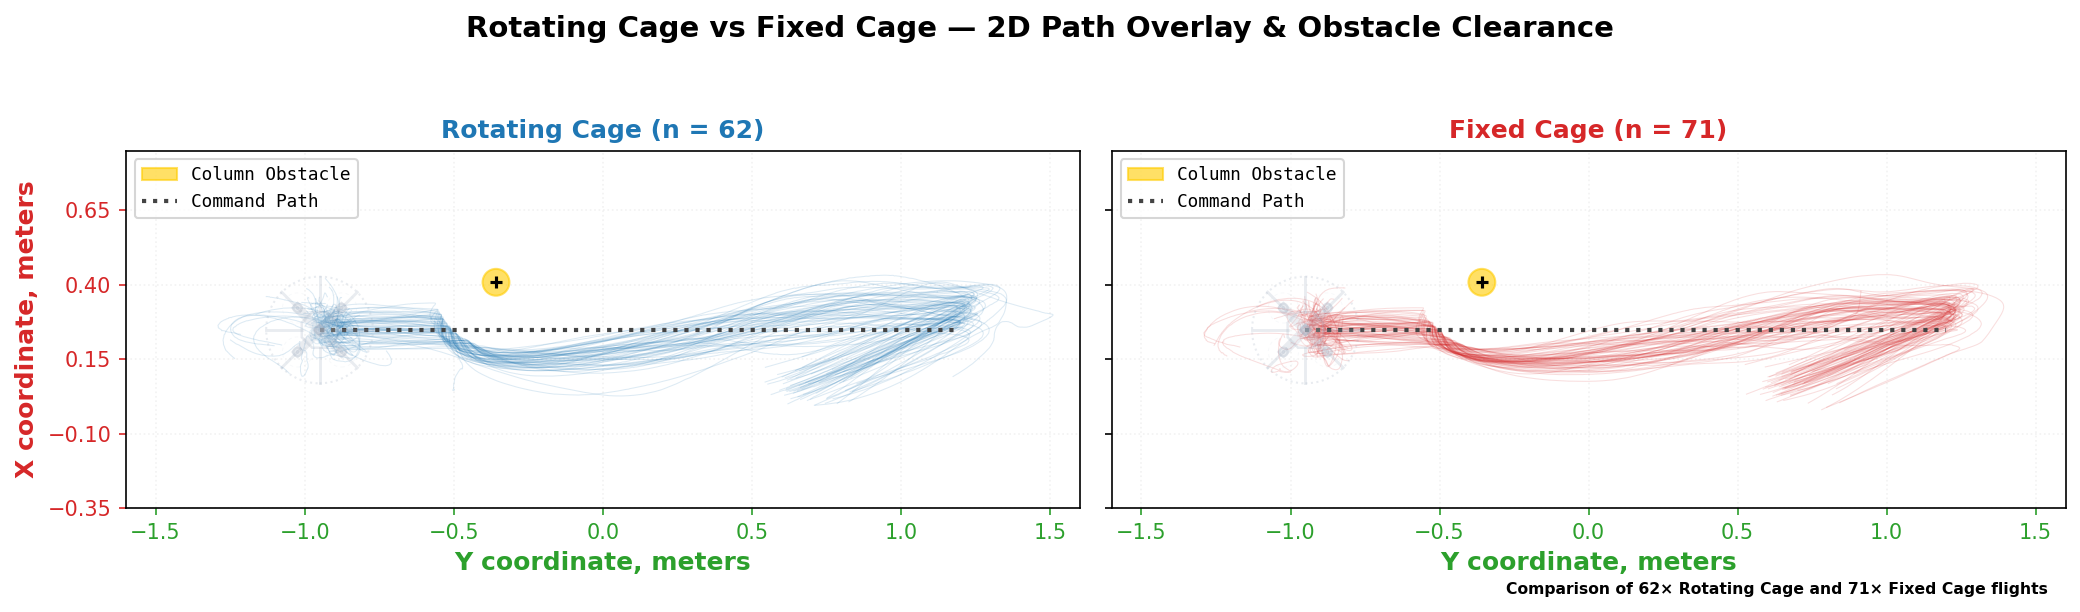

In [20]:
# ─── Plot D: 2D Path Overlay ──────────────────────────────────────────
plot_2d_path_overlay()


[INFO] Saved → graphics/advanced_thesis_highlights.png


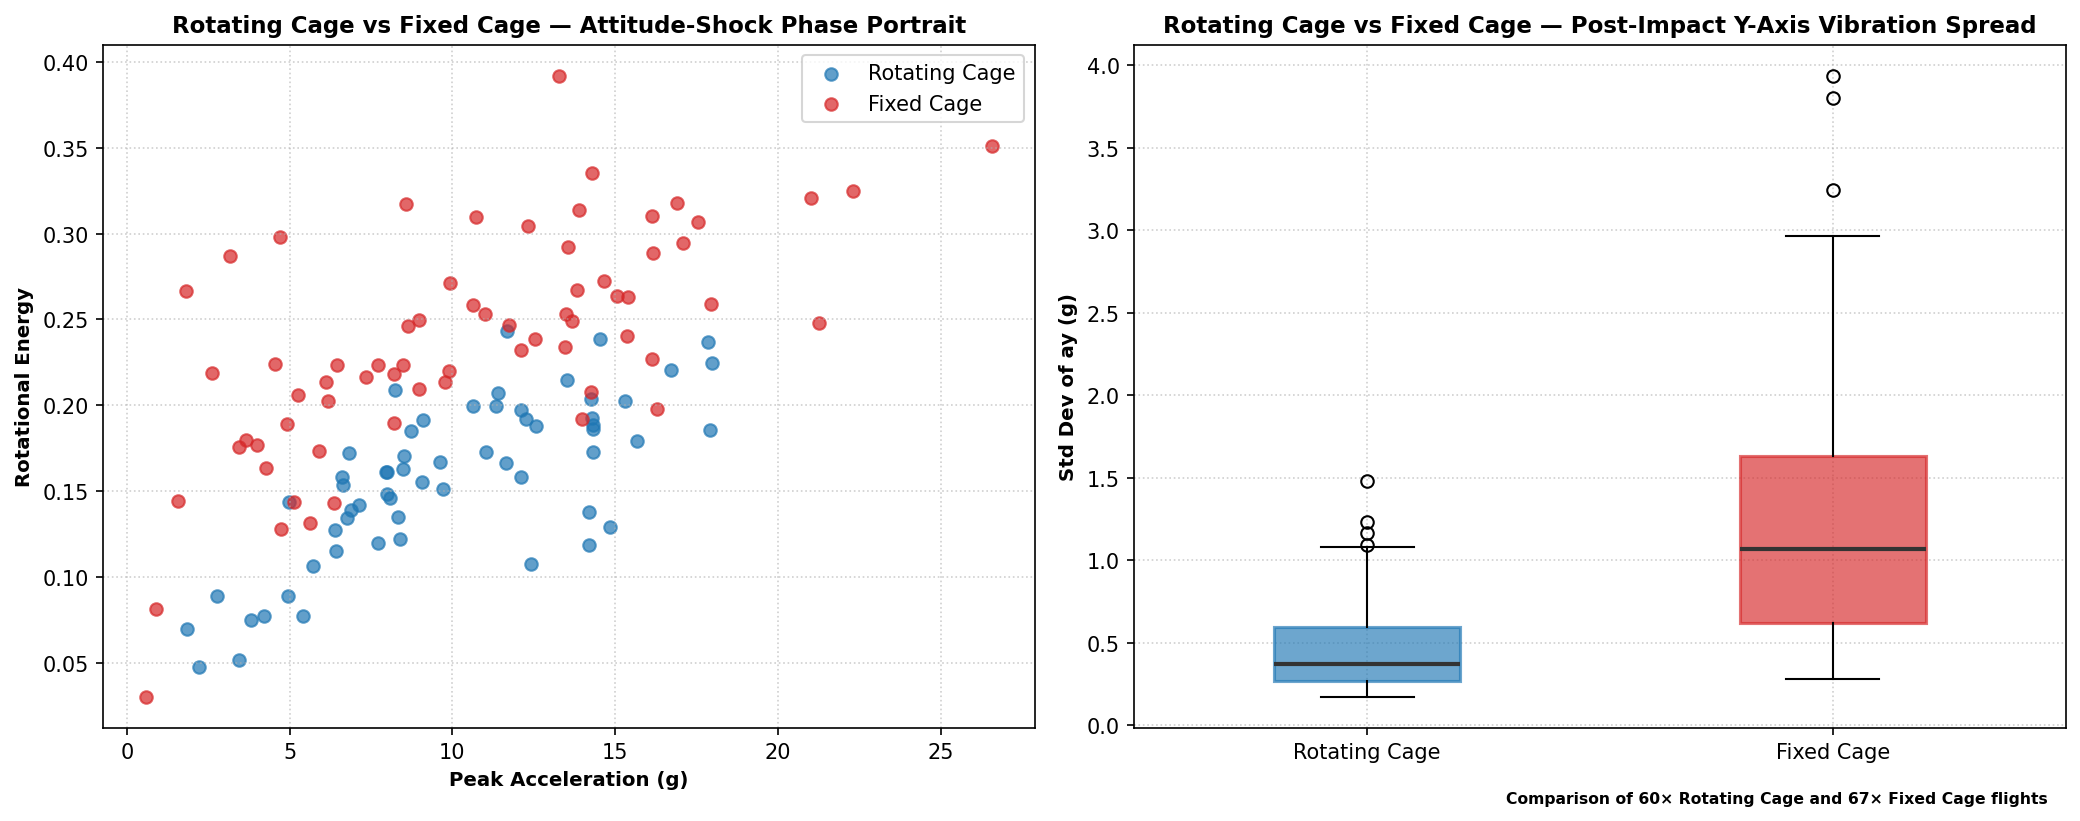

In [21]:
# ─── Attitude-Shock Phase Portrait + Vibration ─────────────────────────
plot_attitude_shock_phase_portrait(df_impacts)


### 📈 3. STATISTICAL AGGREGATE PERFORMANCE ANALYSIS
This section queries the SQLite database to generate comparative boxplots, scatterplots, and heatmaps across all passes, forming the primary quantitative findings of the thesis.

#### 🔬 Statistical Techniques

**Boxplots** below use standard Tukey conventions: box = IQR [Q1, Q3], whiskers = 1.5×IQR, fliers = points beyond whiskers.

**Between-condition comparison tests**:
- **Welch's t-test** (`scipy.stats.ttest_ind, equal_var=False`): Tests for mean difference without assuming equal variance between cage types.  Uses Welch-Satterthwaite degrees of freedom correction.
- **Mann-Whitney U** (`scipy.stats.mannwhitneyu`): Non-parametric rank-sum test — no normality assumption.  Used as robustness check alongside Welch's.
- **Cohen's d**: `(μ₁ − μ₂) / √((σ₁² + σ₂²)/2)` — standardized effect size.  |d| < 0.2 negligible, 0.2–0.5 small, 0.5–0.8 medium, >0.8 large.

**Error bars** on cross-angle plots show **SEM** (Standard Error of the Mean): `σ/√n` — quantifies precision of the mean estimate, not data spread.

[INFO] Saved → graphics/plot_17_allocator_saturation_comparison.png


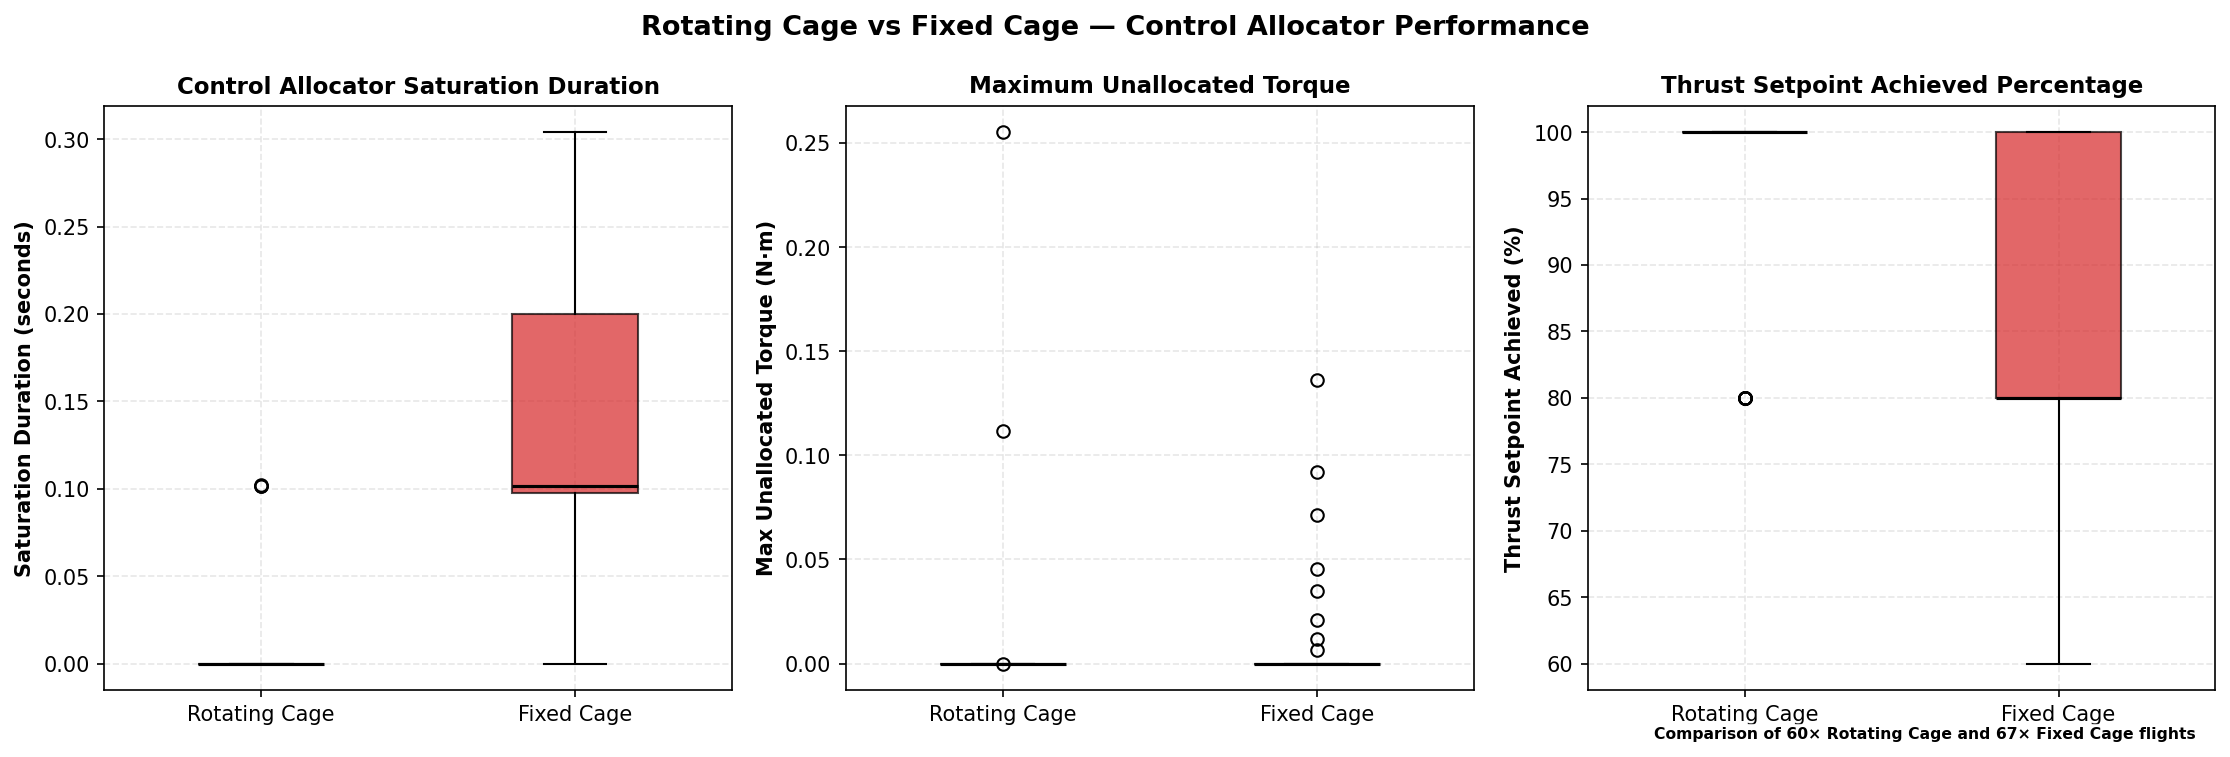

In [22]:
# ─── Allocator Saturation Comparison ────────────────────────────────────
plot_allocator_saturation(df_impacts)


[INFO] Saved → graphics/plot_18_pid_tracking_comparison.png


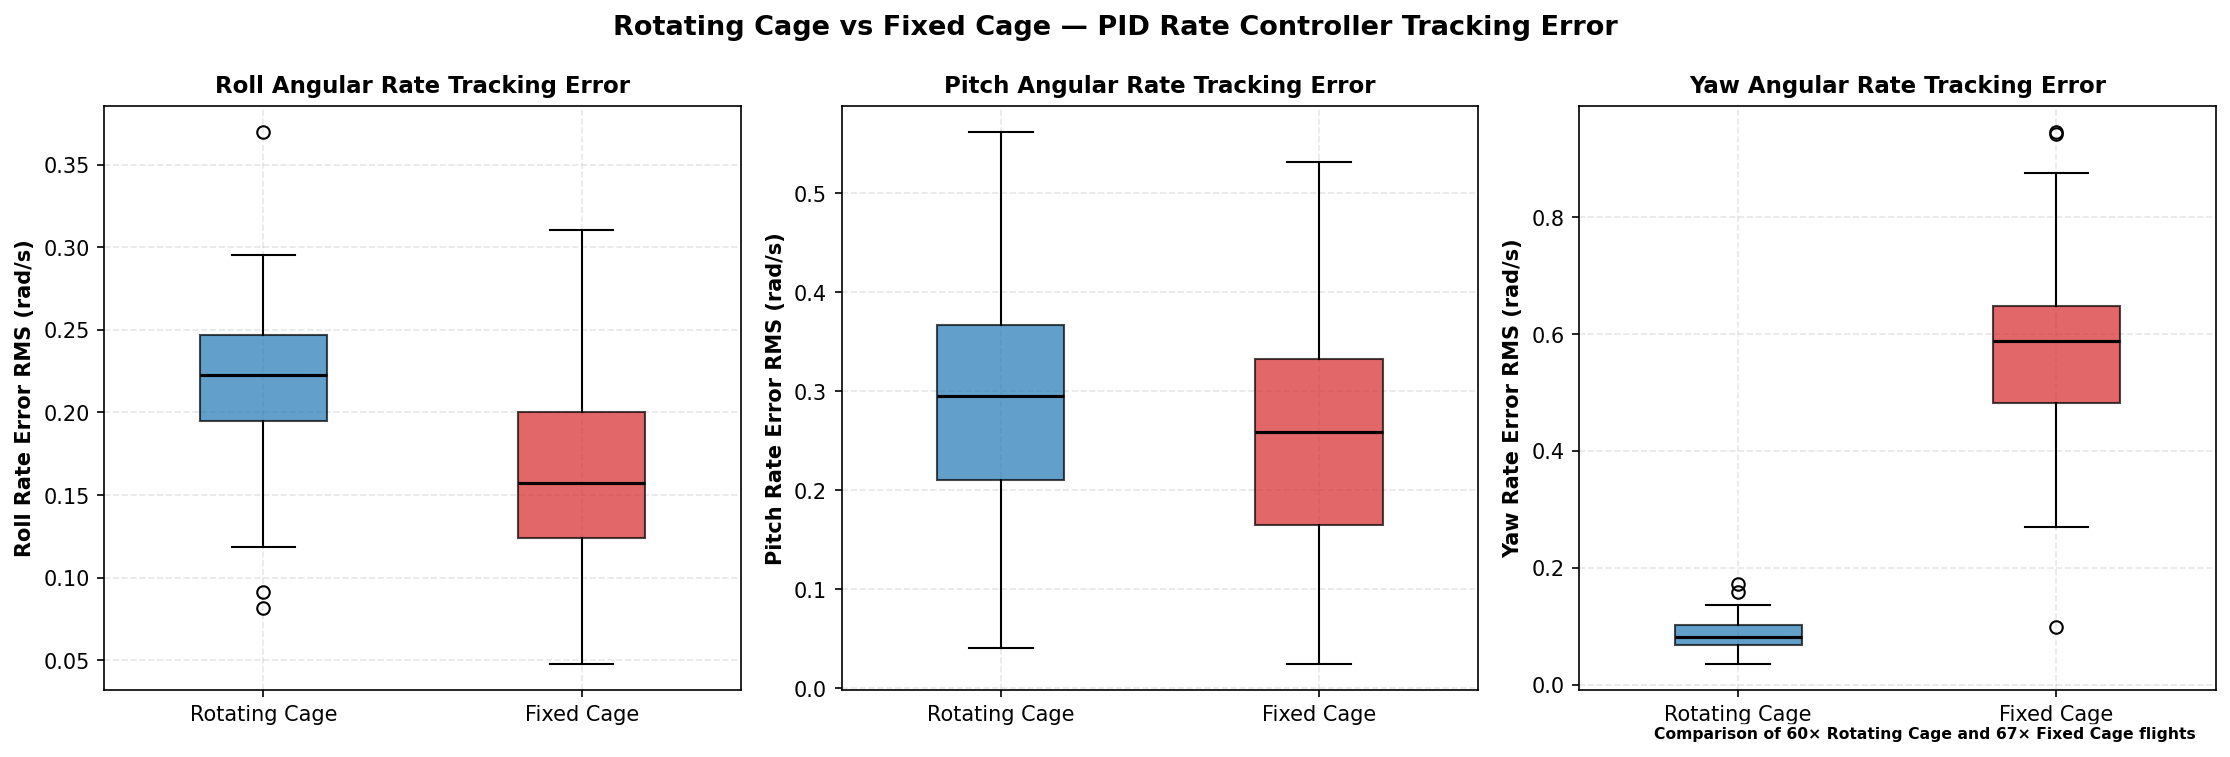

In [23]:
# ─── PID Rate Tracking Error Comparison ────────────────────────────────
plot_pid_tracking_error(df_impacts)


---
### 📉 4. AGGREGATED IMU COLLISION DYNAMICS
This section displays the time-normalized IMU collision dynamics traces for all impact flights, effectively superimposing physical acceleration and gyro reactions.


#### 🔬 Aggregated IMU Technique

**Data source**: `db_cache_imu.py` → `imu_cache.pkl` — pre-extracted, time-aligned IMU traces for all 137 impact flights.

**Alignment**: Each flight's IMU data is aligned to its `Column Impact` timestamp (detected via speed peak search in `kin_calculator.py:find_waypoint_events`).  Time is expressed as `t_rel = t − t_impact`.

**Aggregation**: Per-condition traces are grouped, and at each time step the **mean ± SEM** is computed across all flights.  The shaded band shows the 95% confidence interval of the mean.

**Why cached**: Loading 137 MCAPs (200MB+ each) would take ~20 minutes and >30GB RAM.  The pickle cache loads in <1 second.

Loaded 127 IMU traces.
Rotating: 60 traces, Fixed: 67 traces
Aggregated IMU plot saved to dev_logs/analysis/graphics/plot_19_aggregated_imu_dynamics.png
Aggregated IMU plot saved to thesis/plots/Aggregated IMU Collision Dynamics Across All Flights.png


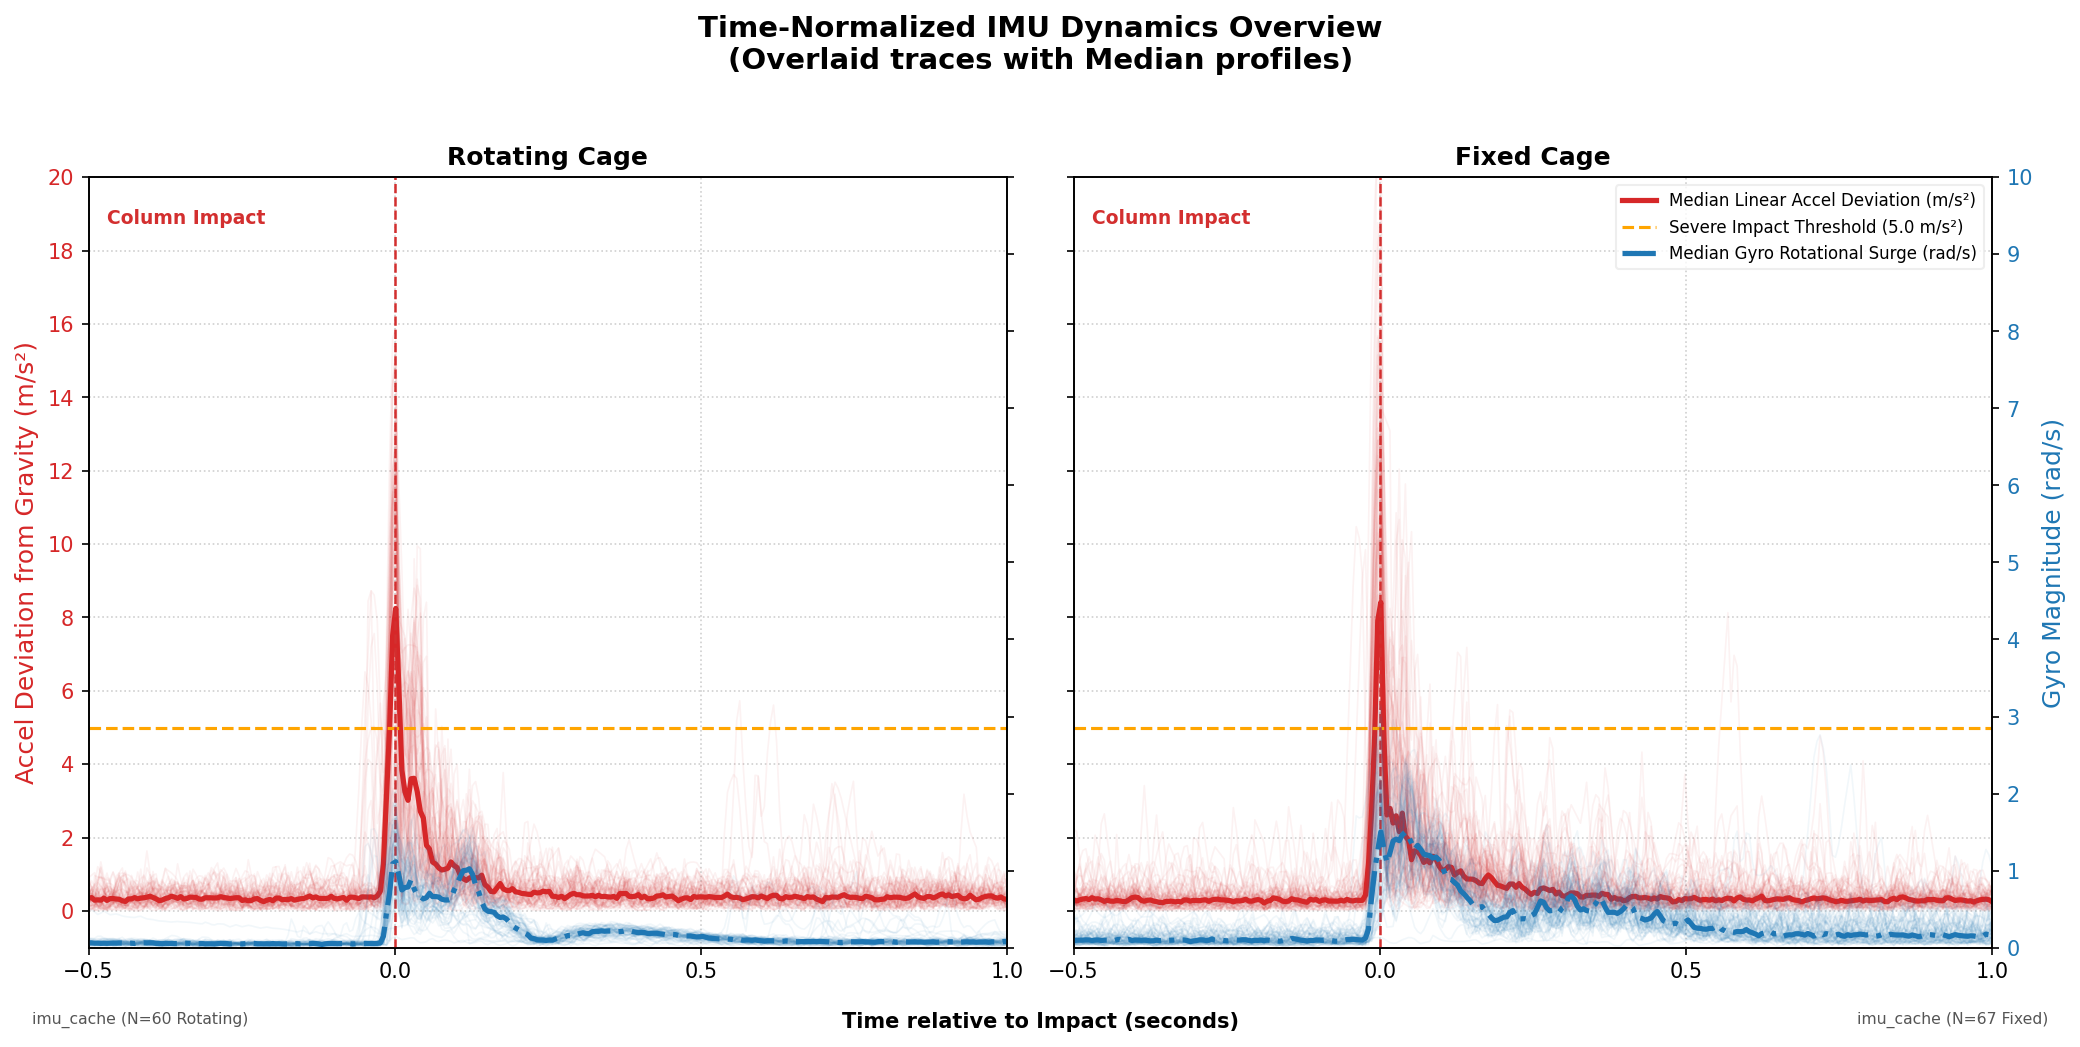

In [24]:
import sys, os
project_root = os.path.abspath(os.path.join(os.path.abspath(''), "../../"))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Plot 19: Aggregated IMU Collision Dynamics
from dev_logs.analysis.graphics.plot_aggregated_imu_dynamics import generate_aggregated_imu_plot
generate_aggregated_imu_plot()


### 🧮 Master Comparison Metrics Table

The table below presents a comprehensive, dynamically generated comparison of all key performance metrics between the Rotating Cage and Fixed Cage configurations. Data is segmented by impact angle to reveal performance trends across mission profiles.

**Table Structure:**
- **Overall (All Angles):** All detected impacts across both 45° and 75° mission profiles
- **45° Impact Angle Subset:** Impacts in the 35°–55° range (shallow-angle sweep missions)
- **75° Impact Angle Subset:** Impacts in the 65°–90° range (steep-angle sweep missions)

Each metric reports **Mean ± Standard Deviation** with the **% Improvement** of Rotating Cage over Fixed Cage (negative = Rotating Cage reduces the metric, which is generally desirable for deviation/error metrics).


### 🏗️ Structural Dynamics Boxplots
![Structural Dynamics Boxplots](graphics/structural_dynamics_boxplots.png)

In [ ]:
# 🏗️ IMU Vibration Spread: Impact vs. Regular Flight
# Generates the XYZ grouped boxplot comparing IMU acceleration spread
# between impact and regular flight windows for both cage configurations.
#
# Data origin: experiments_summary.db → flights_summary (impact_detected==1)
# Window definitions:
#   Impact window:  [t_impact − 50 ms, t_impact + 350 ms] — 400 ms total
#     (50 ms BEFORE impact + 350 ms AFTER impact, centered asymmetrically)
#   Regular window: [t_impact − 1050 ms, t_impact − 50 ms] — 1.0 s pre-impact baseline
# Metrics: Standard deviation of raw IMU accelerometer samples (per axis) in each window.
# Numerical mean ± std values are printed below the plot.
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.path.abspath(''), '../..')))
from dev_logs.analysis.kinematics.kin_plot_imu_spread import plot_imu_spread
plot_imu_spread(df_impacts)
from IPython.display import Image, display
display(Image(filename='graphics/plot_16_imu_vibration_spread.png'))

In [ ]:
    metrics = [
        ("Kinematics",         "Peak Deceleration Z",                        "imu_peak_accel_z",                identity, "m/s²",  True,
         "Max Z-accel (gravity-comp.) in [-0.05,+0.35]s contact win."),
        ("Kinematics",         "Delta-V Z",                                  "imu_delta_v_z",                  identity, "m/s",   True,
         "∫|a_z+g| dt over [-0.05,+0.35]s contact win. — sustained vertical impulse"),
        ("Kinematics",         "Delta-V X",                                  "imu_delta_v_x",                  identity, "m/s",   True,
         "∫|a_x| dt over [-0.05,+0.35]s contact win. — sustained lateral impulse"),
        ("Kinematics",         "Delta-V Y",                                  "imu_delta_v_y",                  identity, "m/s",   True,
         "∫|a_y| dt over [-0.05,+0.35]s contact win. — sustained longitudinal impulse"),
        ("Kinematics",         "Max Trajectory Deviation Magnitude",         "max_dev_after",                   identity, "mm",    True,
         "Max perp. deviation from ideal path, post-impact→WP3"),

## 🔍 Representative Flight Finder

Find the most "average" (representative) flight in each category — the flight whose multivariate distance from the category centroid is smallest.

Use this to pick flights for single-flight thesis plots without cherry-picking.

In [ ]:
from dev_logs.analysis.database.representative_finder import RepresentativeFlightFinder

# ─── Rotating Cage (all angles) ───
finder_rot = RepresentativeFlightFinder(condition="Rotating Cage", df_impacts=df_rot)
finder_rot.print_summary(top_n=3)

In [ ]:
# ─── Fixed Cage (all angles) ───
finder_fix = RepresentativeFlightFinder(condition="Fixed Cage", df_impacts=df_fix)
finder_fix.print_summary(top_n=3)